In [1]:
import numpy as np
import os
import sys
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from functools import  partial
parent_dir = os.path.dirname(os.environ["GTE_DIR"].replace("Glaciation_time_estimator",""))
GTE_DIR=os.environ["GTE_DIR"]
sys.path.insert(0, parent_dir)
from glaciation_time_estimator.data_postprocessing.Job_result_fp_generator import generate_tracking_filenames
from glaciation_time_estimator.auxiliary_func.config_reader import read_config

In [2]:
def Extract_array_from_df(series: pd.Series):
    if series.empty:
        return None
    return np.stack(series.values)

def get_glaciations_df(config):
    agg_fact = config['agg_fact']
    folder_name = f"{config['start_time'].strftime(config['time_folder_format'])}_{config['end_time'].strftime(config['time_folder_format'])}"
    pole=config["pole_folders"][0]
    fp = os.path.join(
                config['postprocessing_output_dir'],
                pole,
                folder_name,
                f"Agg_{agg_fact:02}_Glaciations.parquet"
            )
    try:
        return pd.read_parquet(fp)
    except FileNotFoundError:
        print(f"Skipping glaciations")
        return 

def get_combined_cloud_df(config):
    t_deltas = config['t_deltas']
    agg_fact = config['agg_fact']
    min_temp_array, max_temp_array = config['min_temp_arr'], config['max_temp_arr']
    folder_name = f"{config['start_time'].strftime(config['time_folder_format'])}_{config['end_time'].strftime(config['time_folder_format'])}"
    # Initialize an empty list to store the individual dataframes
    cloud_properties_df_list = []
    copy_next=False
    # Iterate over each temperature range
    for i in range(len(min_temp_array)):
        cloud_properties_df_list.append([])
        min_temp = min_temp_array[i]
        max_temp = max_temp_array[i]

        # Iterate over each pole
        for pole in config["pole_folders"]:
            # Construct the file path
            fp = os.path.join(
                config['postprocessing_output_dir'],
                pole,
                folder_name,
                f"Agg_{agg_fact:02}_T_{abs(round(min_temp)):02}_{abs(round(max_temp)):02}.parquet"
            )

            # Read the parquet file into a dataframe
            try:
                df = pd.read_parquet(fp)
            except FileNotFoundError:
                print(f"Skipping all clouds file: {pole} {min_temp} to {max_temp}")
                copy_next=True
                continue
            
            # Add columns for min_temp, max_temp, and pole
            df['min_temp'] = min_temp
            df['max_temp'] = max_temp
            df['pole'] = pole
            df['Hemisphere'] = "South" if pole == "sp" else "North"
            df['Lifetime [h]'] = df['track_length'] / pd.Timedelta(hours=1)
            df["Radius [km]"]=np.sqrt(df["avg_size[km]"]/np.pi)
            # Append the dataframe to the sublist
            cloud_properties_df_list[i].append(df)
            if copy_next:
                cloud_properties_df_list[i].append(df)
                copy_next=False
    # Combine all dataframes into a single dataframe
    if len(cloud_properties_df_list)==0:
        return None
    return pd.concat(
        [df for sublist in cloud_properties_df_list for df in sublist], ignore_index=True)

In [3]:
df_dict={}
dt_checked=[15,12,9,6,3]
for dt in dt_checked:
    name=f"/cluster/work/climate/dnikolo/n2o/Glaciation_time_estimator/configs/noise_test_tracking/dt_{dt:02}.yaml"
    print(name)
    config = read_config(name)
    df_dict[dt]=get_combined_cloud_df(config)

/cluster/work/climate/dnikolo/n2o/Glaciation_time_estimator/configs/noise_test_tracking/dt_15.yaml


FileNotFoundError: [Errno 2] No such file or directory: '/cluster/work/climate/dnikolo/n2o/Glaciation_time_estimator/configs/noise_test_tracking/dt_15.yaml'

In [4]:
# tracked_area=[None for i in range(len(dt_checked))]
result_df=pd.DataFrame(columns=["Mean tracked area","Cloud count"],index=dt_checked)
for i, dt in enumerate(dt_checked):
    print(i)
    combined_cloud_df = df_dict[dt]
    T_tot=(config["end_time"]-config["start_time"])/timedelta(hours=1)
    combined_cloud_df["norm_area"] = combined_cloud_df["avg_size[km]"] * combined_cloud_df["Lifetime [h]"]/T_tot
    result_df.loc[dt, "Mean tracked area"]= combined_cloud_df["norm_area"].sum()
    result_df.loc[dt, "Cloud count"] = len(combined_cloud_df)


0


KeyError: 15

In [5]:
result_df=pd.read_parquet("/wolke_scratch/dnikolo/Glaciation_time_estimator/Prototyping_files/Sensitivity_test_values.parquet")

In [6]:
T_tot

NameError: name 'T_tot' is not defined

The cloud cover over the test dataset time (01-15.Jan.2022) is 1.246265e+07

In [7]:
cloud_cover = 1.246265e+07+1.452707e+07

In [8]:
result_df["Mean tracked area"]

15    6.669565e+06
12    7.543323e+06
9     8.805224e+06
6     9.448112e+06
3     7.916553e+06
Name: Mean tracked area, dtype: float64

In [9]:
result_df["noise_fraction"]= (cloud_cover - result_df["Mean tracked area"])/cloud_cover

In [10]:
result_df["noise_fraction"]

15    0.752885
12    0.720511
9     0.673756
6     0.649937
3     0.706683
Name: noise_fraction, dtype: float64

In [11]:
config = read_config(
    os.path.join(GTE_DIR,'configs/2022_tracking/01_01.yaml'))
analyze_year=True
year=2022
global global_rmse
global_rmse = config["Global_sqrt_mse"]
classifiacation_palette = ['#e41a1c', '#377eb8', "#4daf4a"]
temperature_palette = ['#eff3ff','#c6dbef','#9ecae1','#6baed6','#3182bd','#08519c']
red_temperature_palette  = ['#fee5d9','#fcbba1','#fc9272','#fb6a4a','#de2d26','#a50f15']

In [12]:
# result_df.to_parquet("/cluster/work/climate/dnikolo/n2o/Glaciation_time_estimator/Prototyping_files/Sensitivity_test_values.parquet")

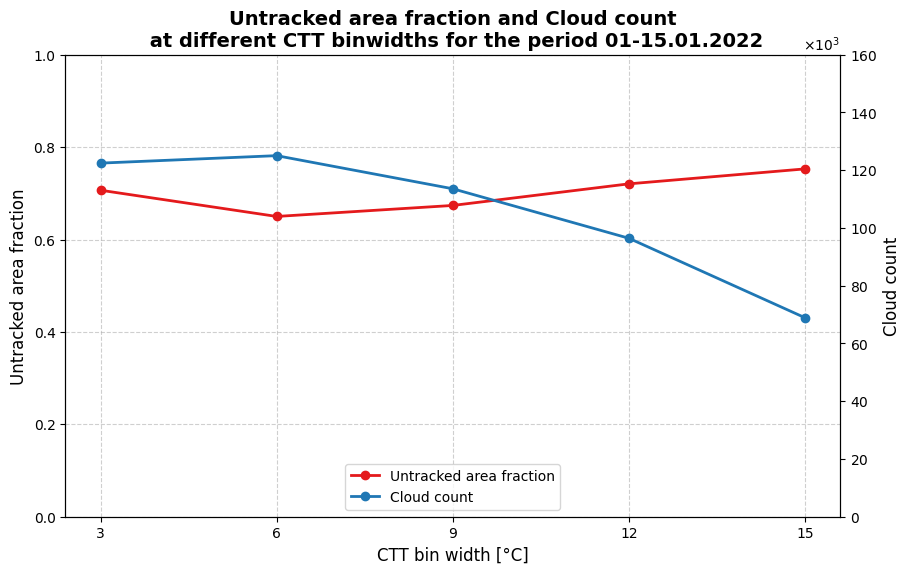

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

# Assuming result_df is your dataframe and it has "Cloud count" and "Mean tracked area" columns.
df = result_df.reset_index()

# Create the figure and primary axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot "Mean tracked area" on the left y-axis (primary axis)
color1 = classifiacation_palette[0]
# formatter = ScalarFormatter(useMathText=True)
# formatter.set_scientific(True)
# formatter.set_powerlimits((7,7))
# ax1.yaxis.set_major_formatter(formatter)
ax1.set_ylim(0,1)
line1, = ax1.plot(df['index'], df['noise_fraction'], 
                  marker='o', linewidth=2, color=color1, label='Untracked area fraction')
# ax1.set_xlabel('Index', fontsize=12)
# ax1.set_ylabel('Mean tracked area', fontsize=12, color=color1)
# ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xlabel('CTT bin width [°C]', fontsize=12)
ax1.set_ylabel('Untracked area fraction', fontsize=12)
ax1.tick_params(axis='y')

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()
color2 = classifiacation_palette[1]
# ax2.set_ylabel('Cloud count', fontsize=12, color=color2)
# line2, = ax2.plot(df['index'], df['Cloud count'], 
#                   marker='o', linewidth=2, color=color2, label='Cloud count')
# ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylabel('Cloud count', fontsize=12)
line2, = ax2.plot(df['index'], df['Cloud count'], 
                  marker='o', linewidth=2, label='Cloud count')
ax2.tick_params(axis='y')
# Force the right axis to display in scientific notation (thousands) with 1e3 offset
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((3,3))
ax2.yaxis.set_major_formatter(formatter)
# Title and grid styling similar to your example
plt.title("Untracked area fraction and Cloud count\n at different CTT binwidths for the period 01-15.01.2022", fontsize=16, fontweight='bold')
ax1.grid(True, linestyle="--", alpha=0.6)

# Combine legends from both axes
lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, title="", loc="lower center", frameon=True, fontsize=10, title_fontsize=11)

# Set x-axis ticks exactly at the index values
ax1.set_xticks(df['index'])
ax2.set_ylim(0,160e3)
# plt.xlim(3,15)
# plt.show()
filename = os.path.join(GTE_DIR,"Result_graphs/dt_sensitivity_test_area_count")
plt.savefig(filename + ".pdf", dpi=400)
plt.savefig(filename + ".png", dpi=400)
